# Who is the best Formula 1 driver of all time?

Formula 1 has always been a difficult sport to assess from a statistical perspective. Although teams have huge amounts of data to work with (and undoubtedly are doing so), practically none of it is publicly accessible. Additionally, Formula 1 is and always has been an engineering competition first, and a driving competition second, a fact that is often forgotten by fans of the sport. The speed of competing cars in any given season can vary drastically, which greatly restricts our ability to easily assess driver talent. In other sports such as basketball or soccer, we can at least be assured that the playing field is relatively even. However, in Formula 1 we can only compare drivers to those who drive the same car as them - their teammates, which significantly lessens the number of comparisons that we can perform for each driver, not helped by the fact that for much of Formula 1's history, each team only fielded a pair of drivers at any given race. It is with this approach that we attempt to derive a driver's true talent level independent of factors that are outside their control.

In [2]:
from tqdm import tqdm
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pygam import LinearGAM, s, f, l, te

import f1_rating_model_functions  as func
import imp
imp.reload(func)

C:\Users\Jack Sun\AppData\Local\Temp\ipykernel_13192\4024972156.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp


<module 'f1_rating_model_functions' from 'h:\\Random files\\Data analyst\\f1\\f1 data analysis\\f1 rating model\\f1_rating_model_functions.py'>

In [3]:
results=pd.read_csv("results.csv")
races=pd.read_csv("races.csv")
drivers=pd.read_csv("drivers.csv")
constructors=pd.read_csv("constructors.csv")
status=pd.read_csv("status.csv")

## 1. Cleaning data

In [4]:
# merging tables

results_concat=results.merge(races, how='left', on='raceId')
results_concat=results_concat.merge(drivers, how='left', on='driverId')
results_concat=results_concat.merge(constructors, how='left', on='constructorId')
results_concat=results_concat.merge(status, how='left', on='statusId')

results_concat['driver_name']=results_concat['forename']+" "+results_concat['surname']
results_concat=results_concat.rename({'name_x':'race_name', 'name_y':'constructor_name'}, axis=1)
results_concat['constructor_year']=results_concat['year'].astype('str')+" "+results_concat['constructor_name']
results_concat=results_concat.loc[results_concat['race_name']!='Indianapolis 500',:]

results_concat=results_concat[[
    'year',
    'round',
    'date',
    'race_name',
    'driver_name',
    'dob',
    'constructor_year',
    'positionOrder',
    'status'
]]

results_concat.head(3)

,year,round,date,race_name,driver_name,dob,constructor_year,positionOrder,status
0,2008,1,2008-03-16,Australian Grand Prix,Lewis Hamilton,1985-01-07,2008 McLaren,1,Finished
1,2008,1,2008-03-16,Australian Grand Prix,Nick Heidfeld,1977-05-10,2008 BMW Sauber,2,Finished
2,2008,1,2008-03-16,Australian Grand Prix,Nico Rosberg,1985-06-27,2008 Williams,3,Finished


In [5]:
# classifying finish status

results_full=results_concat
results_full.loc[results_full['status'].str.contains('Finished|Lap'), 'status']='finished'
results_full.loc[results_full['status'].str.contains('Accident|Collision|Spun'), 'status']='retired_human_error'
results_full.loc[(~(results_full['status'].str.contains('retired_human_error')))&(~(results_full['status'].str.contains('finished'))),'status']='retired_technical_error'

# creating technical problems dummy variable
results_full.loc[results_full['status']=='retired_technical_error', 'technical_problems']=1
results_full['technical_problems']=results_full['technical_problems'].fillna(0)

# creating human error dummy variable
results_full.loc[results_full['status']=='retired_human_error', 'human_error']=1
results_full['human_error']=results_full['human_error'].fillna(0)

# determining number of drivers in each race

results_full=results_full.merge(results_full.loc[results_full['status']=='finished', :].groupby(['year', 'race_name']).agg('count')['round'].reset_index(), on=['year', 'race_name'], how='left')
results_full=results_full.merge(results_full.groupby(['year', 'race_name']).agg('count')['round_x'].reset_index(), on=['year', 'race_name'], how='left', suffixes=(None, '_x'))
results_full=results_full.rename({'round_x':'round', 'round_y':'num_finishing_drivers', 'round_x_x':'num_drivers'}, axis=1)
results_full['dnf_ratio']=(results_full['num_drivers']-results_full['num_finishing_drivers'])/results_full['num_drivers']

# filtering out drivers with less than 5 total finishes

min_races_filter=results_full.loc[results_full['status'].str.contains('finished'), :]
min_races_filter=min_races_filter.groupby(['driver_name']).size().reset_index(name='count').sort_values('count', ascending=False)
min_races_filter=min_races_filter.loc[min_races_filter['count']>=5, :]

results_full=results_full.merge(min_races_filter['driver_name'], how='inner', on='driver_name')

# determining years of experience, capped at 4

pre_1950_drivers=pd.read_csv("earliest_drivers.csv")
pre_1950_drivers=pre_1950_drivers.loc[pre_1950_drivers['raced_flag']>0, ['driver_name', 'year']]

num_races=results_full.groupby(['driver_name', 'year']).agg(num_races=('driver_name', 'count')).reset_index()
num_races=num_races.loc[num_races['num_races']>=3, :]
num_races=pd.concat([num_races, pre_1950_drivers], axis=0).sort_values(['driver_name', 'year'])
num_races['num_races']=num_races['num_races'].fillna('pre_f1_counted')

yoe=pd.concat([results_full, pre_1950_drivers])
yoe=yoe.groupby('driver_name').agg(
        first_year=('year', 'min')
        ,last_year=('year', 'max')
    ).reset_index()
yoe=yoe.merge(pd.DataFrame(np.arange(1946, datetime.date.today().year+1), columns=['year']), how='cross')
yoe=yoe.loc[(yoe['year']>=yoe['first_year'])&(yoe['year']<=yoe['last_year']), ['driver_name', 'year']]
yoe=yoe.merge(num_races, on=['driver_name', 'year'], how='left')
yoe['yoe']=yoe.groupby('driver_name')['num_races'].transform(lambda x: x.shift().rolling(4, 0).count())
results_full=results_full.merge(yoe[['driver_name', 'year', 'yoe']], on=['driver_name', 'year'], how='left')

# determining age and years from prime

results_full['dob']=pd.to_datetime(results_full['dob'])
results_full['date']=pd.to_datetime(results_full['date'])
results_full['age']=(results_full['date']-results_full['dob']).dt.days/365.25
results_full.loc[results_full['age']<25, 'years_from_prime']=25-results_full['age']
results_full.loc[results_full['age']>30, 'years_from_prime']=results_full['age']-30
results_full.loc[results_full['years_from_prime'].isna(), 'years_from_prime']=0

# adding yoe for drivers that started earlier than 1953

earliest_drivers=results_full.groupby('driver_name').agg({'year':'min'}).reset_index()
earliest_drivers=earliest_drivers.loc[earliest_drivers['year']<=1953, 'driver_name'].unique()

# creating a copy of the table for future use before dummies are created and dropping unnecessary columns

results_pred=results_full
results_pred=results_full.drop(['date', 'dob', 'num_finishing_drivers'], axis=1)

# creating dummies for drivers and constructor-year pairs

results_full=pd.concat([results_full, pd.get_dummies(results_full['driver_name'])], axis=1).drop(['driver_name'], axis=1)
results_full=pd.concat([results_full, pd.get_dummies(results_full['constructor_year'])], axis=1).drop(['constructor_year'], axis=1)

# sorting values for alignment and clarity

results_full=results_full.sort_values(['year', 'round', 'positionOrder'], ascending=[False, True, True])

## 2. Ridge regression

In [6]:
# split data into X and y

X_ridge=results_full.drop([
    'year',
    'round',
    'date',
    'num_finishing_drivers',
    'race_name',
    'dob',
    'status',
    'positionOrder',
    'age'
], axis=1)

y_ridge=results_full['positionOrder']

X_ridge.columns

Index(['technical_problems', 'human_error', 'num_drivers', 'dnf_ratio', 'yoe',
       'years_from_prime', 'Adrian Sutil', 'Aguri Suzuki', 'Alain Prost',
       'Alan Brown',
       ...
       '2024 Alpine F1 Team', '2024 Aston Martin', '2024 Ferrari',
       '2024 Haas F1 Team', '2024 McLaren', '2024 Mercedes', '2024 RB F1 Team',
       '2024 Red Bull', '2024 Sauber', '2024 Williams'],
      dtype='object', length=1254)

In [7]:
# fit ridge regression and evaluate results

ridge=func.fit_model(Ridge(), X_ridge, y_ridge)

Fitting model...
Complete 

Evaluation results: 
MAE: 2.73
R-squared: 0.781


## 3. GAM

In [11]:
X_gam=results_full.drop([
    'year',
    'round',
    'date',
    'race_name',
    'num_finishing_drivers',
    'dob',
    'status',
    'positionOrder',
    'years_from_prime'
], axis=1)

y_gam=results_full['positionOrder']

X_gam.columns

Index(['technical_problems', 'human_error', 'num_drivers', 'dnf_ratio', 'yoe',
       'age', 'Adrian Sutil', 'Aguri Suzuki', 'Alain Prost', 'Alan Brown',
       ...
       '2024 Alpine F1 Team', '2024 Aston Martin', '2024 Ferrari',
       '2024 Haas F1 Team', '2024 McLaren', '2024 Mercedes', '2024 RB F1 Team',
       '2024 Red Bull', '2024 Sauber', '2024 Williams'],
      dtype='object', length=1254)

In [12]:
# creating GAM terms

gam_terms=l(0)+l(1)+l(2)+l(3)+s(4, n_splines=4)+s(5, n_splines=8)

for n in range(6, len(X_ridge.columns)):
    gam_terms=gam_terms+l(n)

In [13]:
gam=func.fit_model(LinearGAM(gam_terms), X_gam, y_gam)

Fitting model...
Complete 

Evaluation results: 
MAE: 2.72
R-squared: 0.781


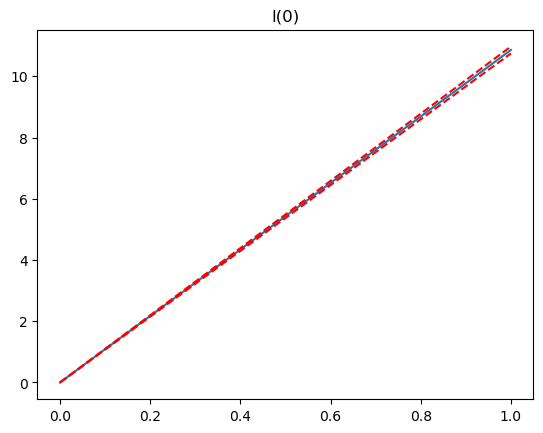

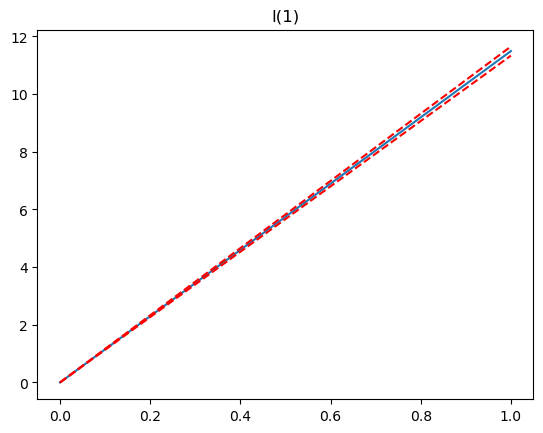

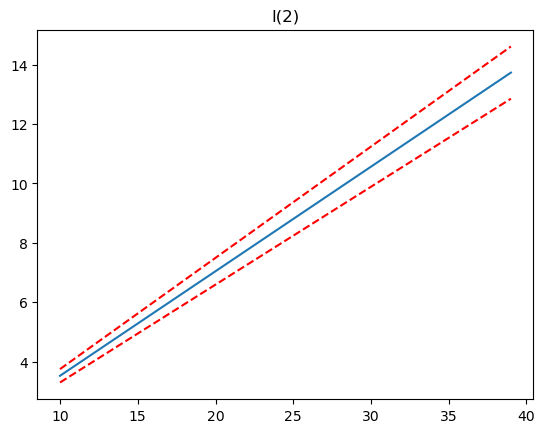

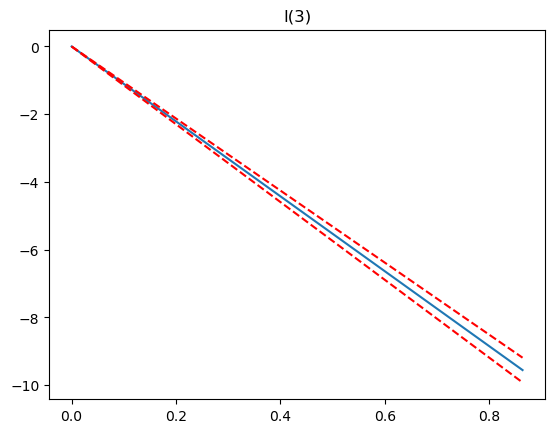

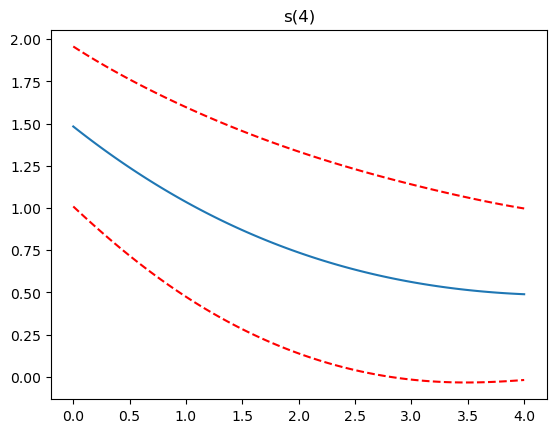

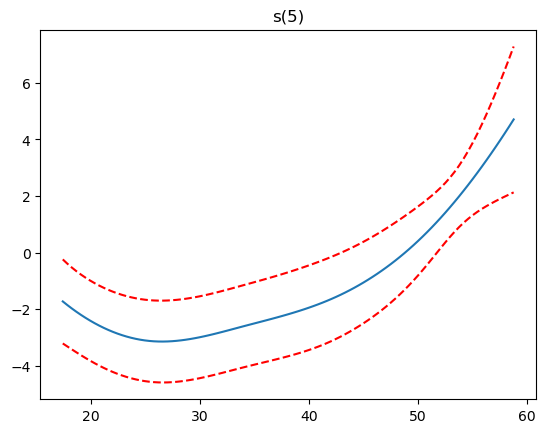

In [91]:
for i, term in enumerate(l(0)+l(1)+l(2)+l(3)+s(4)+s(5)):
    if term.isintercept:
        continue

    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], confi, c='r', ls='--')
    plt.title(repr(term))
    plt.show()

## 4. Model comaprison

In [19]:
# generate rankings (top 25)

import f1_rating_model_functions  as func
imp.reload(func)
ridge_rankings=func.get_rankings(results_pred, ridge, X_ridge, 'ridge', save_results=True).reset_index(drop=True).head(25)
gam_rankings=func.get_rankings(results_pred, gam, X_gam, 'gam', save_results=True).reset_index(drop=True).head(25)

pd.concat([ridge_rankings, gam_rankings], axis=1)

,driver_name,3yma_score,driver_name,3yma_score
0,Fernando Alonso,-5.283257,Lando Norris,0.737832
1,Max Verstappen,-5.259190,Max Verstappen,0.873946
2,Lando Norris,-4.920443,Charles Leclerc,1.013370
3,Jackie Stewart,-4.893623,Fernando Alonso,1.049329
4,Nino Farina,-4.818719,Michael Schumacher,1.603823
5,Lewis Hamilton,-4.722611,Lewis Hamilton,1.713456
6,Juan Fangio,-4.570449,Jackie Stewart,1.728645
7,Graham Hill,-4.521074,Carlos Sainz,1.775067
8,Stirling Moss,-4.452155,Nino Farina,1.923726
9,Michael Schumacher,-4.449881,Tom Pryce,1.944521


In [1]:
# things to do
    # consider model that ranks based on prediction instead of using just prediction
    # consider other features?
        # which features are actually necessary to be in model? which should just be left in variance, unaccounted for?
    # run pygam but w/ logistic linking function to enforce bounds on dependent variable? research other possibilities.